In [1]:
import numpy as np
import datetime
import pandas as pd
import random

In [2]:
def data1():
    X=pd.read_csv('temp.csv')
    X = X.iloc[29:]  # Keep rows from index 19 onwards (0-based index)
    # Ensure 'Open' and 'Close' are treated as numeric
    X['cashopen']=0
    X['cash']=0
    # Ensure columns have float dtype before assignment
    X['cashopen'] = X['cashopen'].astype(float)
    X['cash'] = X['cash'].astype(float)
    X['action']=""
    X['diff']=""
    X['quantity']=""
    return X
    

In [3]:
X=data1()

In [4]:
print(len(X))

2816


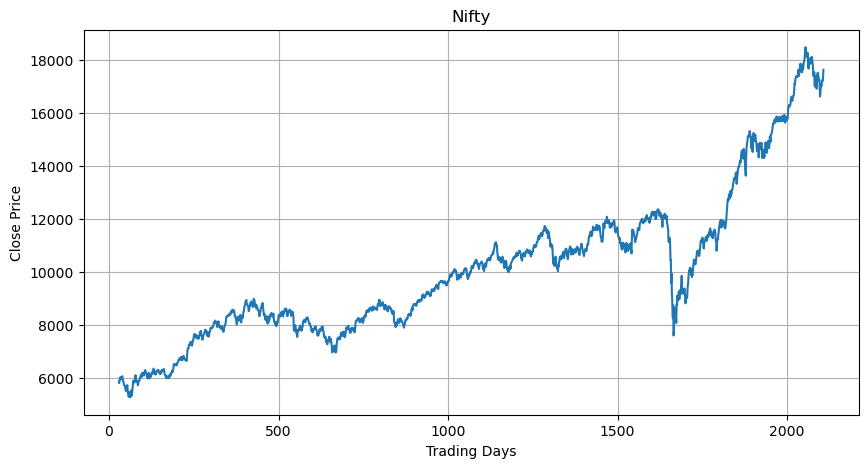

In [5]:
import matplotlib.pyplot as plt
import numpy as np
fig = plt.figure()
ax=X.loc[1:2107,'Close'].plot(grid="True",figsize=(10,5), title='Nifty')
ax.set_xlabel("Trading Days")
ax.set_ylabel("Close Price")
plt.show()
fig.savefig('nifty_close.png')

In [6]:
X.head()

,Unnamed: 0,index,Close,High,Low,Open,Volume,date,weekday,month,...,PVT,Target,lstmstate,p_co,state,cashopen,cash,action,diff,quantity
29,29,129,5859.000000,5864.950195,5834.600098,5834.600098,110400,09-07-2013,0.25,0.545455,...,0.378788,2,2.0,0.186037,5.0,0.0,0.0,,,
30,30,130,5816.700195,5879.350098,5802.850098,5869.899902,117500,10-07-2013,0.50,0.545455,...,0.377365,0,2.0,1.337525,5.0,0.0,0.0,,,
31,31,131,5935.100098,5948.850098,5887.950195,5894.500000,120200,11-07-2013,0.75,0.545455,...,0.381469,2,2.0,1.101917,5.0,0.0,0.0,,,
32,32,132,6009.000000,6019.000000,5951.149902,6000.500000,127700,12-07-2013,1.00,0.545455,...,0.384137,1,2.0,-0.296219,2.0,0.0,0.0,,,
33,33,133,6030.799805,6038.200195,5980.950195,5991.200195,116300,15-07-2013,0.00,0.545455,...,0.384844,2,2.0,-1.658155,2.0,0.0,0.0,,,


In [7]:
X['state'].value_counts()

state
5.0    931
3.0    765
2.0    410
0.0    383
4.0    226
1.0    100
Name: count, dtype: int64

In [8]:
#X.head()

In [9]:
def getState(t):
    t = int(t)
    return(X['state'][t])  

In [10]:
class Agent:
    def __init__(self):
        self.epsilon = 1.0
        self.gamma = 0.618
        self.epsilon_decay = 0.995
        self.epsilon_min = 0.01
        self.Q = np.matrix(np.zeros([6,3]))
        self.learning_rate=0.03
        
    def getAction(self,state):
        state = int(state)
        a=[1,0,2]
        if np.random.rand() <= self.epsilon:
            return random.choice(a)
        return np.argmax(self.Q[state,])  
    
    # Update Q(s,a):= Q(s,a) + lr [R(s,a) + gamma * max Q(s',a') - Q(s,a)]
    def update(self,state,action,reward,next_state,next_action):
        state = int(state)
        action = int(action)
        next_state = int(next_state)
        self.Q[state,action]= self.Q[state,action] + self.learning_rate * (reward + self.gamma * np.max(self.Q[next_state, :])
                                                                - self.Q[state,action])

        

In [11]:
episode_count=100
agent=Agent()
agent.Q
m1=0
m2=0
for e in range(1,episode_count+1):
    X=data1()
    
    data_length_start=30
    data_length=2107
    state = getState(data_length_start-1)
    action = agent.getAction(state)
    
  
    capital=X.loc[data_length_start,'Open']*10
    margin=X.loc[data_length_start,'Open']*10
    #X.loc[2,'cashopen']=margin 
    X.loc[2, 'cashopen'] = float(margin)
    brok_rate=0.0000
    #brok_rate=0.0
    
    print("Episod {}/{}".format(e,episode_count))
    count=0
    for t in range(data_length_start,data_length):
                
        reward=0                        
         
        if action == 1:
            X.loc[t,'cashopen']=float(margin)
            quantity=margin//X.loc[t,'Open']
            X.loc[t,'quantity']=quantity
            margin=margin%X.loc[t,'Open']
            tbrokerage=(X.loc[t,'Open']+X.loc[t,'Close'])*brok_rate
            tprofit=(X.loc[t,'Close']-X.loc[t,'Open']-tbrokerage)*quantity
            margin=margin+tprofit+X.loc[t,'Open']*quantity
            X.loc[t,'cash']=float(margin)         
            
            #print('Long: open price @',X.loc[t,'Open'],'Close price @',X.loc[t,'Close'], 'profit=',tprofit)
            X.loc[t,'action']="long"
            X.loc[t,'diff']=(X.loc[t,'Close']-X.loc[t,'Open']-tbrokerage)*quantity
            count=count+1
            reward= max((np.log(X.loc[t,'Close'])-np.log(X.loc[t,'Open']+tbrokerage)),0)
            
       
        elif action == 2:
            X.loc[t,'cashopen']=float(margin) 
            quantity=margin//X.loc[t,'Open']
            X.loc[t,'quantity']=(-quantity)
            margin=margin%X.loc[t,'Open']
            tbrokerage=(X.loc[t,'Open']+X.loc[t,'Close'])*brok_rate
            tprofit=(X.loc[t,'Open']-X.loc[t,'Close']-tbrokerage)*quantity
            #print('in Short')
            margin=margin+tprofit+X.loc[t,'Open']*quantity
            X.loc[t,'cash']=float(margin)         
            last_action='Short'
            #print('Short: Close price @',X.loc[t,'Close'],'Open price @',X.loc[t,'Open'], 'profit=',tprofit)
            X.loc[t,'action']="short"
            X.loc[t,'diff']=(X.loc[t,'Open']-X.loc[t,'Close']-tbrokerage)*quantity
            count=count+1
            reward= max((np.log(X.loc[t,'Open'])-np.log(X.loc[t,'Close']+tbrokerage)),0)
           
        else:
            X.loc[t,'cash']=margin
            X.loc[t,'action']="Hold"
            X.loc[t,'diff']=0
            reward=0                                  
              
        next_state=int(getState(t))
        next_action=agent.getAction(next_state)
        agent.update(state,action,reward,next_state,next_action)
        state=next_state
        action=next_action
        
        if t==data_length-1:
                print("\n***********************\n",t)
                print("Profit is ",(margin-capital))
                print("Initial Capital is ",capital)    
                print("Current Capital is ",margin)
                roi=((margin-capital)/capital)*100
                print("%ROI is ",roi)
                bnh=((X.loc[t,'Close']-X.loc[data_length_start,'Open'])/X.loc[data_length_start,'Open'])*100
                print("% Buy and Hold=",bnh)
                print("count",count)
                print("qtable",agent.Q)
                print("epsilon",agent.epsilon)
                print("--------------------------------")
                       
        if (agent.epsilon > agent.epsilon_min) and e>1:
                       agent.epsilon *= agent.epsilon_decay
                       
    
    m3=roi
    if m3>m2:
        m1=e
        m2=m3
    #To save model  
    if e%20==0:
        np.save('rl/Qtable'+ str(e)+str('.npy'), agent.Q)
        np.save('rl/epsilon'+ str(e)+str('.npy'), agent.epsilon)
        np.save('rl/gamma'+ str(e)+str('.npy'), agent.gamma)
        np.save('rl/learning_rate'+ str(e)+str('.npy'), agent.learning_rate)
        X.to_csv('csv1/AfterTrain'+str(e)+str('.csv'))
print("e={},roi={}".format(m1,m2))

Episod 1/100

***********************
 2106
Profit is  13190.227827000228
Initial Capital is  58698.99902
Current Capital is  71889.22684700023
%ROI is  22.470958699834107
% Buy and Hold= 195.64474811720564
count 1384
qtable [[0.00474425 0.00668499 0.0099879 ]
 [0.00176613 0.00313433 0.0045263 ]
 [0.00504979 0.01099101 0.00802246]
 [0.00584753 0.00699739 0.01155296]
 [0.00313371 0.0037539  0.0045523 ]
 [0.00587844 0.00969125 0.00790105]]
epsilon 1.0
--------------------------------
Episod 2/100

***********************
 2106
Profit is  7541895.89406001
Initial Capital is  58698.99902
Current Capital is  7600594.89308001
%ROI is  12848.423346180612
% Buy and Hold= 195.64474811720564
count 1998
qtable [[0.00529263 0.00715362 0.01471342]
 [0.00183527 0.00346478 0.00838422]
 [0.00571336 0.01183072 0.0082847 ]
 [0.00598463 0.00773267 0.01462274]
 [0.00353219 0.00463318 0.00760878]
 [0.00629988 0.01028925 0.00769286]]
epsilon 0.00998645168764533
--------------------------------
Episod 3/100


In [12]:
agent.Q

matrix([[0.00750913, 0.00812011, 0.0148273 ],
        [0.00513855, 0.00569122, 0.00892521],
        [0.00709398, 0.0119146 , 0.00898676],
        [0.00803554, 0.00938575, 0.01457889],
        [0.0059947 , 0.00655054, 0.00789112],
        [0.0069911 , 0.01032427, 0.00813763]])

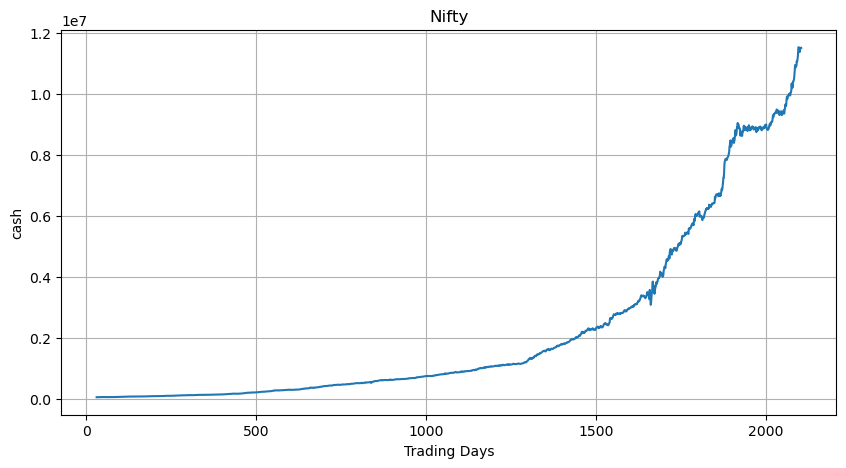

In [13]:
%matplotlib inline
fig = plt.figure()
ax=X.loc[data_length_start:data_length-2,'cash'].plot(grid="True",figsize=(10,5), title='Nifty')
ax.set_xlabel("Trading Days")
ax.set_ylabel("cash")
plt.show()